## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub by clicking the link below. If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information. 


Access the [**Black Marble Nighttime at Sensor Radiance**](https://hub.ghg.center/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2FUS-GHG-Center%2Fghgc-docs&urlpath=lab%2Ftree%2Fghgc-docs%2Fuser_data_notebooks%2Fblackmarble-radiance-daygrid-v2nrt_User_Notebook.ipynb&branch=main) notebook in the US GHG Center JupyterHub (requires access). 



## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Terminology](#terminology)
- [Install the Required Libraries](#install-the-required-libraries)
- [Query the STAC API](#query-the-stac-api)
- [Black Marble Helper Functions](#black-marble-helper-functions)
- [Creating Plot Side-by-Side Images](#creating-plot-side-by-side-images)
- [Nighttime at Sensor Radiance across Florida, New York, and California](#nighttime-at-sensor-radiance-across-florida-new-york-and-california)
- [Fire and Thermal Anomalies Analysis](#fire-and-thermal-anomalies-analysis)
  - [Interactive Fire Overlay](#interactive-fire-overlay)
  - [Side-by-Side Visualization](#side-by-side-visualization)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: Global
- **Spatial resolution**: 30 arc seconds (~500 m)
- **Temporal extent**:  November 18, 2020 - Ongoing
- **Temporal resolution**: Daily
- **Unit**: Nanowatts per square centimeter per steradian (nW/cm²/sr)
- **Utility**: Climate Research

For more, visit the [Black Marble Nighttime at Sensor Radiance](https://earth.gov/ghgcenter/data-catalog/blackmarble-radiance-daygrid-v2nrt) data overview page.


## Approach

This notebook demonstrates how to visualize satellite-derived nighttime at sensor radiance and overlay fire/thermal anomaly data:

1. **Connect to STAC API** - Access the VIIRS Black Marble collection metadata.
2. **Select Dates** - Choose time periods for comparison.
3. **Calculate Tile Coordinates** - Convert geographic coordinates to WMTS tile indices.
4. **Fetch Black Marble Imagery** - Retrieve nighttime at sensor radiance tiles from NASA GIBS.
5. **Retrieve Fire Data** - Access VIIRS thermal anomalies using Mapbox Vector Tiles.
6. **Interactive Selection** - Choose from preset locations or enter custom coordinates.
7. **Side-by-Side Visualization** - Compare Black Marble nighttime at sensor radiance with fire overlay.
8. **Analyze Results** - Distinguish urban lights from fires, volcanoes, and gas flares.

## About the Data
### Black Marble Nighttime at Sensor Radiance
This dataset provides daily, Near Real Time (NRT) nighttime at sensor radiance observed by the Visible Infrared Imaging Radiometer Suite (VIIRS) Day/Night band on board the Suomi National Polar-orbiting Partnership (NPP) satellite. Data are in units of nanoWatts per square centimeter per steradian (nW/cm²/sr) and gridded at 500 meter resolution. This record indexes the layers of this dataset from NASA's WorldView Web Map Tile Service (WMTS) for visualization purposes. The source data and accompanying documentation can be found at https://doi.org/10.5067/VIIRS/VNP46A1_NRT.002.

### VIIRS Fire and Thermal Anomalies
The VIIRS 375m Active Fire product provides data on thermal anomalies and fires detected by the VIIRS sensor at 375-meter resolution, including wildfires, volcanoes, and gas flares. The product includes fire radiative power, brightness temperature, and detection confidence levels, enabling discrimination between different types of thermal sources. For more information and data access, visit the NASA FIRMS website at https://firms.modaps.eosdis.nasa.gov/active_fire/ and the VIIRS Active Fire User Guide.

For more information regarding this dataset, please visit the [Black Marble Nighttime at Sensor Radiance](https://earth.gov/ghgcenter/data-catalog/blackmarble-radiance-daygrid-v2nrt) data overview page.

## Terminology

Navigating data via the GHGC API, you will encounter terminology that is different from browsing in a typical filesystem. We'll define some terms here which are used throughout this notebook.

1.  `catalog`:    All datasets available at the `/stac` endpoint
2.  `collection`: A specific dataset, e.g. BlueFlux CO₂ and Methane Flux
3.  `item`:       One granule in the dataset, e.g. one daily file of carbon fluxes
4.  `asset`:      A variable available within the granule, e.g. net primary productivity or net ecosystem exchange
5.  `STAC API`:   **Sp**atio**T**emporal **A**sset **C**atalogs - Endpoint for fetching metadata about available datasets

## Install the Required Libraries
Required libraries are pre-installed on the GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

%pip install requests pystac_client matplotlib ipywidgets mapbox-vector-tile pillow --quiet

In [2]:
# Import required libraries
import requests
import gzip
from datetime import datetime
from typing import List, Tuple, Dict
from io import BytesIO

# For data visualization
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# For image processing
from PIL import Image

# For vector tile processing
import mapbox_vector_tile

# For accessing the STAC API
from pystac_client import Client

## Query the STAC API
### STAC API Collection Names

Now, you must fetch the dataset from the [**STAC API**](https://earth.gov/ghgcenter/api/stac/) by defining its associated STAC API collection ID as a variable. 
The collection ID, also known as the **collection name**, for the Black Marble Nighttime at Sensor Radiance dataset is [**VIIRS_SNPP_DayNightBand_At_Sensor_Radiance**](https://earth.gov/ghgcenter/api/stac/collections/VIIRS_SNPP_DayNightBand_At_Sensor_Radiance).*

**You can find the collection name of any dataset on the GHGC data portal by navigating to the dataset landing page within the data catalog. The collection name is the last portion of the dataset landing page's URL, and is also listed in the pop-up box after clicking "ACCESS DATA."*

In [3]:
# Provide the STAC and RASTER API endpoints
# The endpoint is referring to a location within the API that executes a request on a data collection nesting on the server.

# The STAC API is a catalog of all the existing data collections that are stored in the GHG Center.
STAC_API_URL = "https://earth.gov/ghgcenter/api/stac"

# The collection name is used to fetch metadata from the STAC API.
COLLECTION_NAME = "VIIRS_SNPP_DayNightBand_At_Sensor_Radiance"

# NASA GIBS WMTS endpoint
WMTS_BASE_URL = "https://gibs-c.earthdata.nasa.gov/wmts/epsg4326/best/wmts.cgi"

# Load collection
catalog = Client.open(STAC_API_URL)
collection = catalog.get_collection(COLLECTION_NAME)
display(collection)


<CollectionClient id=VIIRS_SNPP_DayNightBand_At_Sensor_Radiance>

Each image is broken down into a differing number of tiles when requests for a specific location are provided as inputs. To improve the understanding of which tiles are being plotted when a specfic location is requested, provided below are the dimensions for the entire image when a specific zoom level is requested. Each zoom level has a specific number of tiles which correspond with different regions of the world based on latitude and longitude. 

In [4]:
# Tilematrixset for 500m resolution
TILEMATRIXSET = "500m"

# Tile matrix dimensions from NASA GIBS GetCapabilities. This assists with grabbing the correct tile based on location.
GIBS_500M_TILE_MATRIX = {
    0: {'width': 2, 'height': 1, 'tile_width': 180.0, 'tile_height': 180.0},      # 360°/2 = 180°, 180°/1 = 180°
    1: {'width': 3, 'height': 2, 'tile_width': 120.0, 'tile_height': 90.0},       # 360°/3 = 120°, 180°/2 = 90°
    2: {'width': 5, 'height': 3, 'tile_width': 72.0, 'tile_height': 60.0},        # 360°/5 = 72°, 180°/3 = 60°
    3: {'width': 10, 'height': 5, 'tile_width': 36.0, 'tile_height': 36.0},       # 360°/10 = 36°, 180°/5 = 36°
    4: {'width': 20, 'height': 10, 'tile_width': 18.0, 'tile_height': 18.0},      # 360°/20 = 18°, 180°/10 = 18°
    5: {'width': 40, 'height': 20, 'tile_width': 9.0, 'tile_height': 9.0},        # 360°/40 = 9°, 180°/20 = 9°
    6: {'width': 80, 'height': 40, 'tile_width': 4.5, 'tile_height': 4.5},        # 360°/80 = 4.5°, 180°/40 = 4.5°
    7: {'width': 160, 'height': 80, 'tile_width': 2.25, 'tile_height': 2.25}      # 360°/160 = 2.25°, 180°/80 = 2.25°
}

print("NASA GIBS 500m Tile Matrix Dimensions:")
print("Zoom | Grid Size  | Tile Coverage (degrees)")
print("-----|------------|------------------------")
for zoom, params in GIBS_500M_TILE_MATRIX.items():
    print(f"  {zoom}  | {params['width']:3d}×{params['height']:2d}    | {params['tile_width']:.2f}° × {params['tile_height']:.2f}°")

NASA GIBS 500m Tile Matrix Dimensions:
Zoom | Grid Size  | Tile Coverage (degrees)
-----|------------|------------------------
  0  |   2× 1    | 180.00° × 180.00°
  1  |   3× 2    | 120.00° × 90.00°
  2  |   5× 3    | 72.00° × 60.00°
  3  |  10× 5    | 36.00° × 36.00°
  4  |  20×10    | 18.00° × 18.00°
  5  |  40×20    | 9.00° × 9.00°
  6  |  80×40    | 4.50° × 4.50°
  7  | 160×80    | 2.25° × 2.25°


## Black Marble Helper Functions 

Useful for converting spatial selection to tile numbers, requesting Black Marble data from server, and plotting the requested tile.

1. Convert longitude and latitude coordinates to tile coordinates (function `lonlat_to_tilexy`) <br />
2. Get the bounding box of each tile to ensure that the region of interest is within a specific tile (function `tile_to_bbox`) <br />
3. Fetch the tile via an API request (function `fetch_tile`) <br />
4. Formatting image to identify the latitude and longitude bounds (function `format_coordinate`) <br />
5. Plot the tile for the specified location of interest (function `display_tile_or_error`)

In [5]:
def lonlat_to_tilexy(lon: float, lat: float, zoom: int) -> Tuple[int, int]:
    """
    Convert longitude/latitude to GIBS 500m tile indices.
    """
    if zoom not in GIBS_500M_TILE_MATRIX:
        raise ValueError(f"Zoom level {zoom} not supported. Use 0-7.")
    
    matrix = GIBS_500M_TILE_MATRIX[zoom]
    
    # Calculate tile indices (origin at -180, 90)
    col = int((lon + 180) / matrix['tile_width'])
    row = int((90 - lat) / matrix['tile_height'])
    
    # Clamp to valid range
    col = max(0, min(col, matrix['width'] - 1))
    row = max(0, min(row, matrix['height'] - 1))
    
    return col, row

def tile_to_bbox(col: int, row: int, zoom: int) -> Tuple[float, float, float, float]:
    """
    Get the geographic bounding box for a tile based on the column and row tile request.
    """
    matrix = GIBS_500M_TILE_MATRIX[zoom]
    
    # Calculate exact boundaries based on tile dimensions
    min_lon = -180 + (col * matrix['tile_width'])
    max_lon = min_lon + matrix['tile_width']
    max_lat = 90 - (row * matrix['tile_height'])
    min_lat = max_lat - matrix['tile_height']
    
    return min_lon, max_lon, min_lat, max_lat

def fetch_tile(col: int, row: int, zoom: int, date: str = "2022-09-30T00:00:00Z") -> Image:
    """
    Fetch a single tile from NASA GIBS.
    """
    params = {
        "TIME": date,
        "layer": COLLECTION_NAME,
        "style": "default",
        "tilematrixset": TILEMATRIXSET,
        "Service": "WMTS",
        "Request": "GetTile",
        "Version": "1.0.0",
        "Format": "image/png",
        "TileMatrix": zoom,
        "TileCol": col,
        "TileRow": row
    }
    
    response = requests.get(WMTS_BASE_URL, params=params)
    
    if response.status_code == 200:
        try:
            return Image.open(BytesIO(response.content))
        except Exception as e:
            print(f"❌ Error: Failed to parse image data for tile ({col},{row}) at zoom {zoom}")
            return None
    else:
        print(f"❌ Error: Failed to fetch tile ({col},{row}) at zoom {zoom}")
        return None
    
def pixel_position(img, lon, lat, bbox):

    # Calculate pixel position
    img_width, img_height = img.size
    x_pos = ((lon - bbox[0]) / (bbox[1] - bbox[0])) * img_width
    y_pos = ((bbox[3] - lat) / (bbox[3] - bbox[2])) * img_height
    return x_pos, y_pos

In [6]:
def format_coordinate(value, is_longitude=True):
    """
    Format a coordinate value with appropriate direction indicator. Useful when plotting tiles.
    """
    if is_longitude:
        direction = "E" if value >= 0 else "W"
        abs_value = abs(value)
    else:
        direction = "N" if value >= 0 else "S"
        abs_value = abs(value)
    
    return f"{abs_value:.1f}°{direction}"


def display_tile_or_error(ax, img, date_str, collection_name, bbox=None, zoom_level=None):
    """
    Helper function to display a tile image or an error message if the image is None.
    Adds coordinate labels if bbox is provided (only for zoom levels 2 and above).
    """
    temporal_interval = collection.extent.temporal.intervals[0]
    if img is not None:
        ax.imshow(img)
        
        # Add coordinate labels only for zoom levels 2 and above
        if bbox is not None and zoom_level is not None and zoom_level >= 2:
            min_lon, max_lon, min_lat, max_lat = bbox
            
            # Format corner coordinates 
            left_lon = format_coordinate(min_lon, is_longitude=True)
            right_lon = format_coordinate(max_lon, is_longitude=True)
            
            # For latitude (N/S)
            bottom_lat = format_coordinate(min_lat, is_longitude=False)
            top_lat = format_coordinate(max_lat, is_longitude=False)

            ax.text(1.02, 0.0, bottom_lat, transform=ax.transAxes, 
                   rotation=90, ha='left', va='center', fontsize=8, color='black')
            ax.text(1.02, 1.0, top_lat, transform=ax.transAxes, 
                   rotation=90, ha='left', va='center', fontsize=8, color='black')
            
            # Left corner
            ax.text(0.0, -0.02, left_lon, transform=ax.transAxes, 
                   ha='center', va='top', fontsize=8, color='black')
            # Right corner
            ax.text(0.98, -0.02, right_lon, transform=ax.transAxes, 
                   ha='right', va='top', fontsize=8, color='black')
            
            # Add intermediate tick marks
            for x in [0.25, 0.5, 0.75]:
                lon_val = min_lon + (max_lon - min_lon) * x
                lon_label = format_coordinate(lon_val, is_longitude=True)
                # Bottom
                ax.text(x, -0.02, lon_label, transform=ax.transAxes, 
                       ha='center', va='top', fontsize=7, color='gray')
            
            for y in [0.25, 0.5, 0.75]:
                # Note: y=0 is bottom, y=1 is top in axes coordinates
                # But latitude increases from bottom to top
                lat_val = min_lat + (max_lat - min_lat) * y
                lat_label = format_coordinate(lat_val, is_longitude=False)
                # Right side
                ax.text(1.02, y, lat_label, transform=ax.transAxes, 
                       rotation=90, ha='left', va='center', fontsize=7, color='gray')
        
        ax.axis('off')
        ax.set_title(f"{collection_name}\n{date_str}")
    else:
        # Convert date_str to datetime for comparison
        from datetime import timezone
        date_obj = datetime.strptime(date_str.split('T')[0], '%Y-%m-%d').replace(tzinfo=timezone.utc)
        
        if (date_obj < temporal_interval[0]) or (date_obj > temporal_interval[1]):
            before_or_after = ('before','start') if date_obj < temporal_interval[0] else ('after','end')
            reference_date = temporal_interval[0] if before_or_after[0] == 'before' else temporal_interval[1]
            
            ax.text(0.5, 0.5, 
                    f"⚠️  Warning: Requested date {date_str}\nis {before_or_after[0]} the collection {before_or_after[1]} date\n{reference_date.strftime('%Y-%m-%dT%H:%M:%SZ')}", 
                    ha='center', va='center', fontsize=11, 
                    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="orange", alpha=0.9))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title(f"{collection_name}\n{date_str} - No Data", color='darkorange')

## Creating Plot Side-by-Side Images

### Location: **Los Angeles, California**

We can now select a specific location and datetime to compare Black Marble imagery between two different dates. This can allow us to determine how radiance has changed as a function of time.

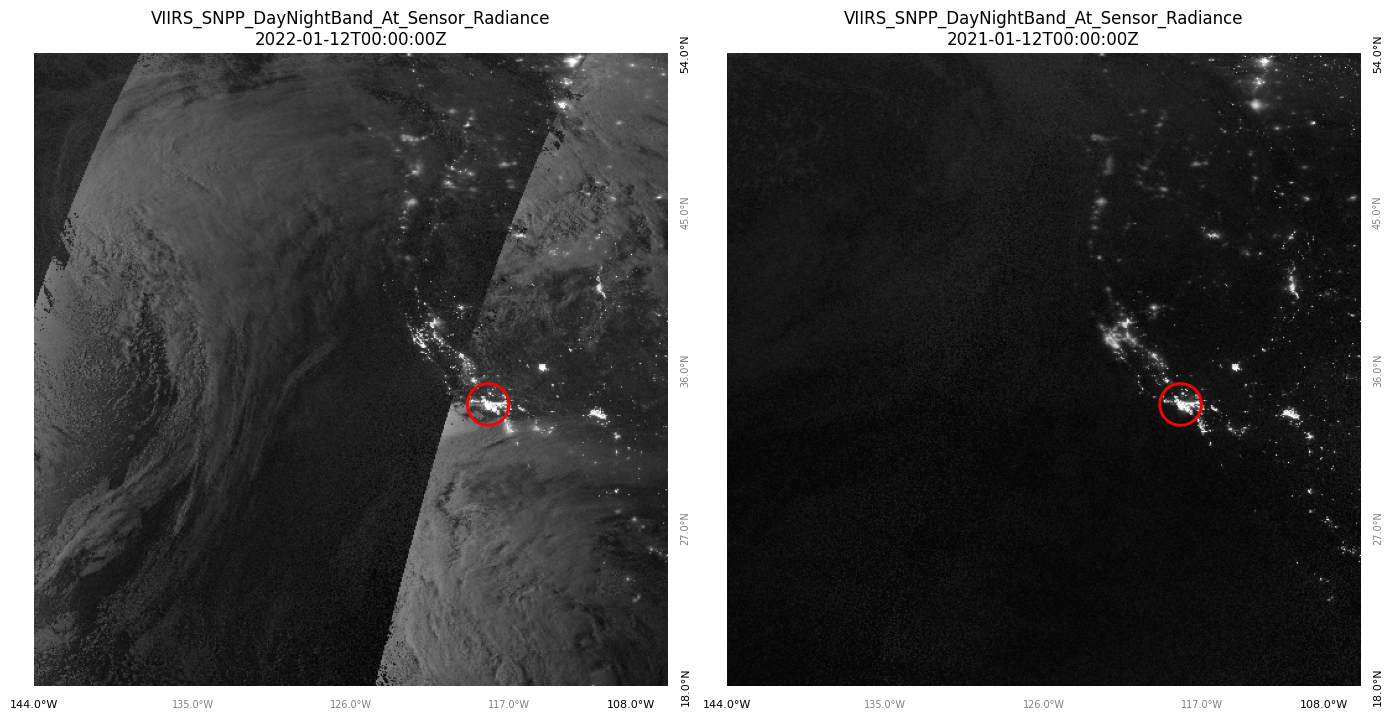

In [7]:
### Arguments
# Dates to compare
dates = ["2022-01-12T00:00:00Z", "2021-01-12T00:00:00Z"]

lon = -118.2437 # West
lat = 34.0522 # North
zoom = 3

# Prepare subplots with extra space for coordinate labels
fig, axs = plt.subplots(1, len(dates), figsize=(14, 7))
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.3)

for ax, date_str in zip(axs, dates):
    col, row = lonlat_to_tilexy(lon, lat, zoom)
    bbox = tile_to_bbox(col, row, zoom)
    img = fetch_tile(col, row, zoom, date_str)
    display_tile_or_error(ax, img, date_str, COLLECTION_NAME, bbox, zoom_level=zoom)

    x_pos, y_pos = pixel_position(img, lon, lat, bbox)
    # Add a red circle at the location
    ax.scatter(x_pos, y_pos, facecolors='none', edgecolors='red', s=900, marker='o', linewidths=2)

plt.tight_layout()
plt.show()

## Nighttime at Sensor Radiance across Florida, New York, and California

We further investigate sensor radiance across the United States to examine regional differences based on the same date. We will enhance the zoom level to 4 on each of these locations to grab tiles that look closer at Earth's surface and show higher definition.

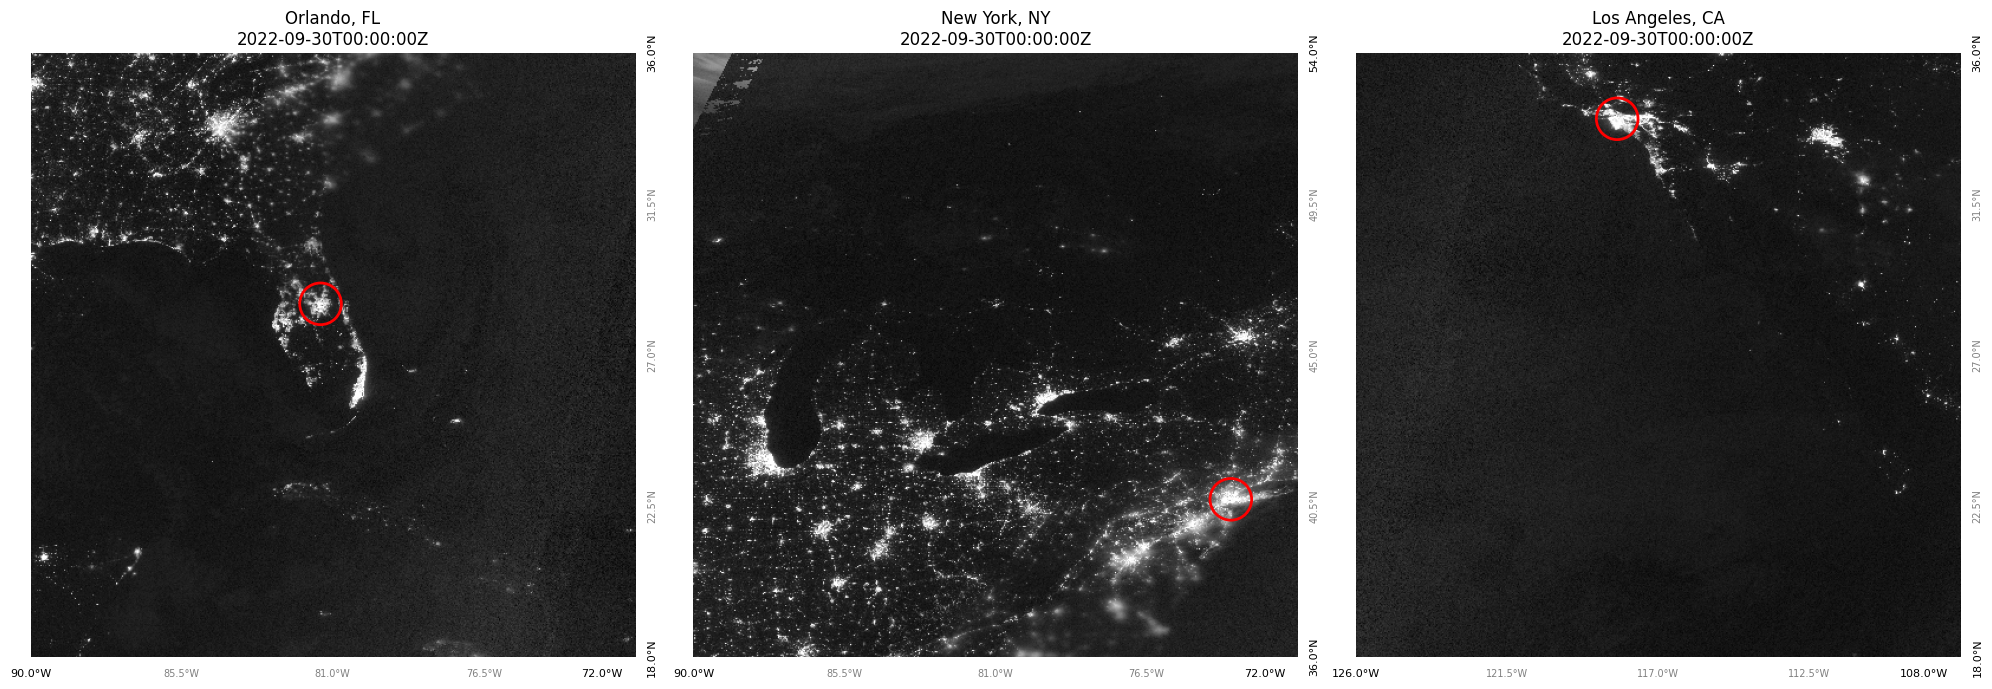

In [8]:
# Example: Multiple locations with coordinate labels
locations = [
    {"name": "Orlando, FL", "lon": -81.3789, "lat": 28.5384},
    {"name": "New York, NY", "lon": -74.0060, "lat": 40.7128},
    {"name": "Los Angeles, CA", "lon": -118.2437, "lat": 34.0522}
]

date = "2022-09-30T00:00:00Z"
zoom = 4

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.08, wspace=0.25)

for ax, location in zip(axes, locations):
    lon, lat = location["lon"], location["lat"]
    
    # Get tile coordinates
    col, row = lonlat_to_tilexy(lon, lat, zoom)
    bbox = tile_to_bbox(col, row, zoom)
    # Fetch and display tile
    img = fetch_tile(col, row, zoom, date)
    display_tile_or_error(ax, img, date, location['name'], bbox, zoom_level=zoom)
    
    # Add a marker for the specific location
    if img is not None:
        x_pos, y_pos = pixel_position(img, lon, lat, bbox)
        # Add a red circle at the location
        ax.scatter(x_pos, y_pos, facecolors='none', edgecolors='red', s=900, marker='o', linewidths=2)

plt.tight_layout()
plt.show()


## Fire and Thermal Anomalies Analysis

While higher radiance values indicate more light emissions, they are not always associated with city lights. For example, **fires and thermal anomalies** can have high radiance values and can be associated with volcanoes or gas flares. These events in particular can release large amounts of carbon dioxide (CO<sub>2</sub>), nitrogen dioxide (NO<sub>2</sub>), or methane (CH<sub>4</sub>) into the atmosphere which can be a public health hazard. Therefore, we further investigate these anomalies using VIIRS (Visible Infrared Imaging Radiometer Suite) fire and thermal anomaly data, available through the [NASA FIRMS](https://viirsland.gsfc.nasa.gov/Products/NASA/FireESDR.html#:~:text=The%20alternative%20375%20m%20fire,available%20starting%20in%20mid%2D2023).

#### We provide an interactive section to examine 3 different regions and events which produce notable fire and thermal anomalies. 
1. **Palisades Fire, Los Angeles** - A devastating urban wildfire that burned through Pacific Palisades in January 2025, threatening homes and forcing mass evacuations.
2. **Kilauea Volcano, Hawaii** - One of the world's most active volcanoes with persistent thermal anomalies from lava lakes and eruptions visible in satellite imagery.
3. **Western Siberia, Russia** - A region with extensive oil and gas operations producing continuous gas flares alongside seasonal boreal forest fires.

In [9]:
# VIIRS Fire and Thermal Anomalies Configuration
FIRE_LAYER = "VIIRS_SNPP_Thermal_Anomalies_375m_All"

# Preset points for fire overlay demonstration with recommended dates
PRESET_POINTS = {
    "Los Angeles, CA": {
        "lon": -118.526, "lat": 34.048,
        "description": "Palisades Fire - Urban Fires and Wildfire Area",
        "recommended_zoom": 5,
        "recommended_date": "2025-01-10"  # Fire season
    },
    "Kilauea Volcano, Hawaii": {
        "lon": -155.2834, "lat": 19.4069,
        "description": "Kilauea Volcano, Hawaii - Active Volcano",
        "recommended_zoom": 6,
        "recommended_date": "2022-01-12"  # Active volcanic period
    },
    "Western Siberia, Russia": {
        "lon": 69.35135, "lat": 60.75285,
        "description": "Western Siberia, Russia - Gas Flares and Boreal Fire Season",
        "recommended_zoom": 6,
        "recommended_date": "2024-09-20"  # As requested
    },
    "Custom: Insert your coordinates and dates": {
        "lon": -100.0, "lat": 40.0,
        "description": "Custom location",
        "recommended_zoom": 5,
        "recommended_date": "2022-01-12"  # Default date
    }
}

### Interactive Fire Overlay

In [10]:
# Create minimal widgets
location_dropdown = widgets.Dropdown(
    options=list(PRESET_POINTS.keys()),
    value='Kilauea Volcano, Hawaii',
    description='Location:'
)

zoom_dropdown = widgets.Dropdown(
    options=[
        ('Zoom 2 - Wide (72°×60°)', 2), 
        ('Zoom 3 - Regional (36°×36°)', 3), 
        ('Zoom 4 - Local (18°×18°)', 4), 
        ('Zoom 5 - Detailed (9°×9°)', 5),
        ('Zoom 6 - High Detail (4.5°×4.5°)', 6),
        ('Zoom 7 - Very High Detail (2.25°×2.25°)', 7)
    ],
    value=6,
    description='Zoom:',
    style={'description_width': 'initial'}
)

# Date picker with initial value from selected location
initial_location = location_dropdown.value
initial_date = PRESET_POINTS[initial_location].get('recommended_date', '2022-01-12')
date_picker = widgets.DatePicker(
    description='Date:',
    value=datetime.strptime(initial_date, '%Y-%m-%d').date()
)

# Custom coordinates (hidden by default)
custom_lon = widgets.FloatText(value=-100.0, description='Longitude:', layout=widgets.Layout(display='none'))
custom_lat = widgets.FloatText(value=40.0, description='Latitude:', layout=widgets.Layout(display='none'))

# Custom location help message (hidden by default)
custom_help = widgets.HTML(
    value="""<div style='background-color: #e8f4f8; padding: 10px; border-radius: 5px; margin-top: 10px; display: none;'>
    <b>📍 Custom Location Instructions:</b><br>
    • Enter longitude (-180 to 180): negative = West, positive = East<br>
    • Enter latitude (-90 to 90): negative = South, positive = North<br>
    • Select your desired date and zoom level<br>
    • Example: Los Angeles is lon: -118.5, lat: 34.0
    </div>""",
    layout=widgets.Layout(display='none')
)

def on_location_change(change):
    """Update date and zoom when location changes."""
    selected_location = change['new']
    location_data = PRESET_POINTS[selected_location]
    
    # Update date picker with recommended date
    if 'recommended_date' in location_data:
        date_picker.value = datetime.strptime(location_data['recommended_date'], '%Y-%m-%d').date()
    
    # Update zoom with recommended zoom
    if 'recommended_zoom' in location_data:
        zoom_dropdown.value = location_data['recommended_zoom']
    
    # Show/hide custom coordinates and help message
    if 'Custom:' in selected_location:
        custom_lon.layout.display = 'block'
        custom_lat.layout.display = 'block'
        custom_help.layout.display = 'block'
        # Update the help div visibility
        custom_help.value = custom_help.value.replace('display: none;', '')
    else:
        custom_lon.layout.display = 'none'
        custom_lat.layout.display = 'none'
        custom_help.layout.display = 'none'

location_dropdown.observe(on_location_change, names='value')

# Display widgets with location-specific date info
display(widgets.VBox([
    widgets.HBox([location_dropdown, zoom_dropdown]),
    widgets.HBox([custom_lon, custom_lat]),
    custom_help,
    date_picker,
    widgets.HTML("<p><i style='font-size: 1.0rem'>Note: Each location has a recommended date with known fire/thermal activity:</i></p>"),
    widgets.HTML("<ul style='font-size: 1.2rem; margin-top: 0;'>" +
                 "<li><b>Palisades Fire, LA</b>: Jan 10, 2025 (devastating urban wildfire)</li>" +
                 "<li><b>Kilauea, Hawaii</b>: Jan 12, 2022 (active volcanic eruption)</li>" +
                 "<li><b>Western Siberia</b>: Sep 20, 2024 (gas flares & boreal fires)</li>" +
                 "</ul>"),
    widgets.HTML("<p style='font-size: 0.95em; color: #666;'><b>Zoom levels:</b> Higher numbers = more zoomed in. " +
                 "Level 6-7 show very detailed local views.</p>")
]))

In [11]:
# Define GIBS base URL for MVT tiles (same as working notebook)
GIBS_MVT_BASE_URL = "https://gibs.earthdata.nasa.gov/wmts/epsg4326/best"

def fetch_fire_mvt_data(col: int, row: int, zoom: int, date_time: str) -> List[Dict]:
    """Fetch fire data from GIBS MVT tiles."""
    # Using the GIBS base URL for fire MVT tiles (same pattern as working notebook)
    url = f"{GIBS_MVT_BASE_URL}/{FIRE_LAYER}/default/{date_time}/500m/{zoom}/{row}/{col}.mvt"
    
    try:
        response = requests.get(url, timeout=15)
        
        if response.status_code == 200 and len(response.content) > 0:
            # Handle gzipped content
            content = response.content
            if content[:2] == b'\x1f\x8b':
                content = gzip.decompress(content)
            
            # Decode MVT
            decoded = mapbox_vector_tile.decode(content)
            
            # Extract fire features
            fires = []
            for layer_name, layer_data in decoded.items():
                if 'features' in layer_data:
                    for feature in layer_data['features']:
                        props = feature.get('properties', {})
                        geom = feature.get('geometry', {})
                        
                        # Extract coordinates - check both properties and geometry
                        lat = lon = None
                        
                        if 'LATITUDE' in props and 'LONGITUDE' in props:
                            lat = props['LATITUDE']
                            lon = props['LONGITUDE']
                        elif geom.get('type') == 'Point' and 'coordinates' in geom:
                            lon, lat = geom['coordinates']
                        
                        if lat is not None and lon is not None:
                            fires.append({
                                'lat': float(lat),
                                'lon': float(lon),
                                'confidence': props.get('CONFIDENCE', 'unknown')
                            })
            
            return fires
        else:
            return []
    except Exception as e:
        print(f"Error fetching fire data: {e}")
        return []

# Fetch data based on widget selections
def get_selected_data():
    """Get data based on current widget selections."""
    location = location_dropdown.value
    zoom = zoom_dropdown.value
    date_str = date_picker.value.strftime('%Y-%m-%d') + "T00:00:00Z"
    
    if location == 'Custom':
        lon, lat = custom_lon.value, custom_lat.value
    else:
        point = PRESET_POINTS[location]
        lon, lat = point['lon'], point['lat']
    
    # Get tile coordinates
    col, row = lonlat_to_tilexy(lon, lat, zoom)
    bbox = tile_to_bbox(col, row, zoom)
    
    # Fetch Black Marble tile
    bm_img = fetch_tile(col, row, zoom, date_str)
    
    # Store Black Marble in tiles dictionary format (like working notebook)
    black_marble_tiles = {}
    if bm_img:
        black_marble_tiles[(col, row)] = bm_img
    
    # Fetch fire data
    fires = fetch_fire_mvt_data(col, row, zoom, date_str)
    
    print(f"✓ Black Marble: {'Loaded' if bm_img else 'No data'}")
    
    # Show sample fires if any
    if fires:
        print(f"✓ Fires: {len(fires)} detected")

    return {
        'location': location,
        'lon': lon,
        'lat': lat,
        'zoom': zoom,
        'date': date_str,
        'col': col,
        'row': row,
        'bbox': bbox,
        'black_marble_tiles': black_marble_tiles,  # Use same structure as working notebook
        'fires': fires
    }

# Execute fetch
data = get_selected_data()

✓ Black Marble: Loaded
✓ Fires: 28 detected


### Side-by-Side Visualization

We will now present figures for Black Marble only (left) and overlay the VIIRS Fire and Thermal Anomalies on top of the Black Marble (right). This will allow us to directly compare where the satellite sensor picks up light emitted by cities or features such as volcanoes, gas flares, or other thermal anomalies.

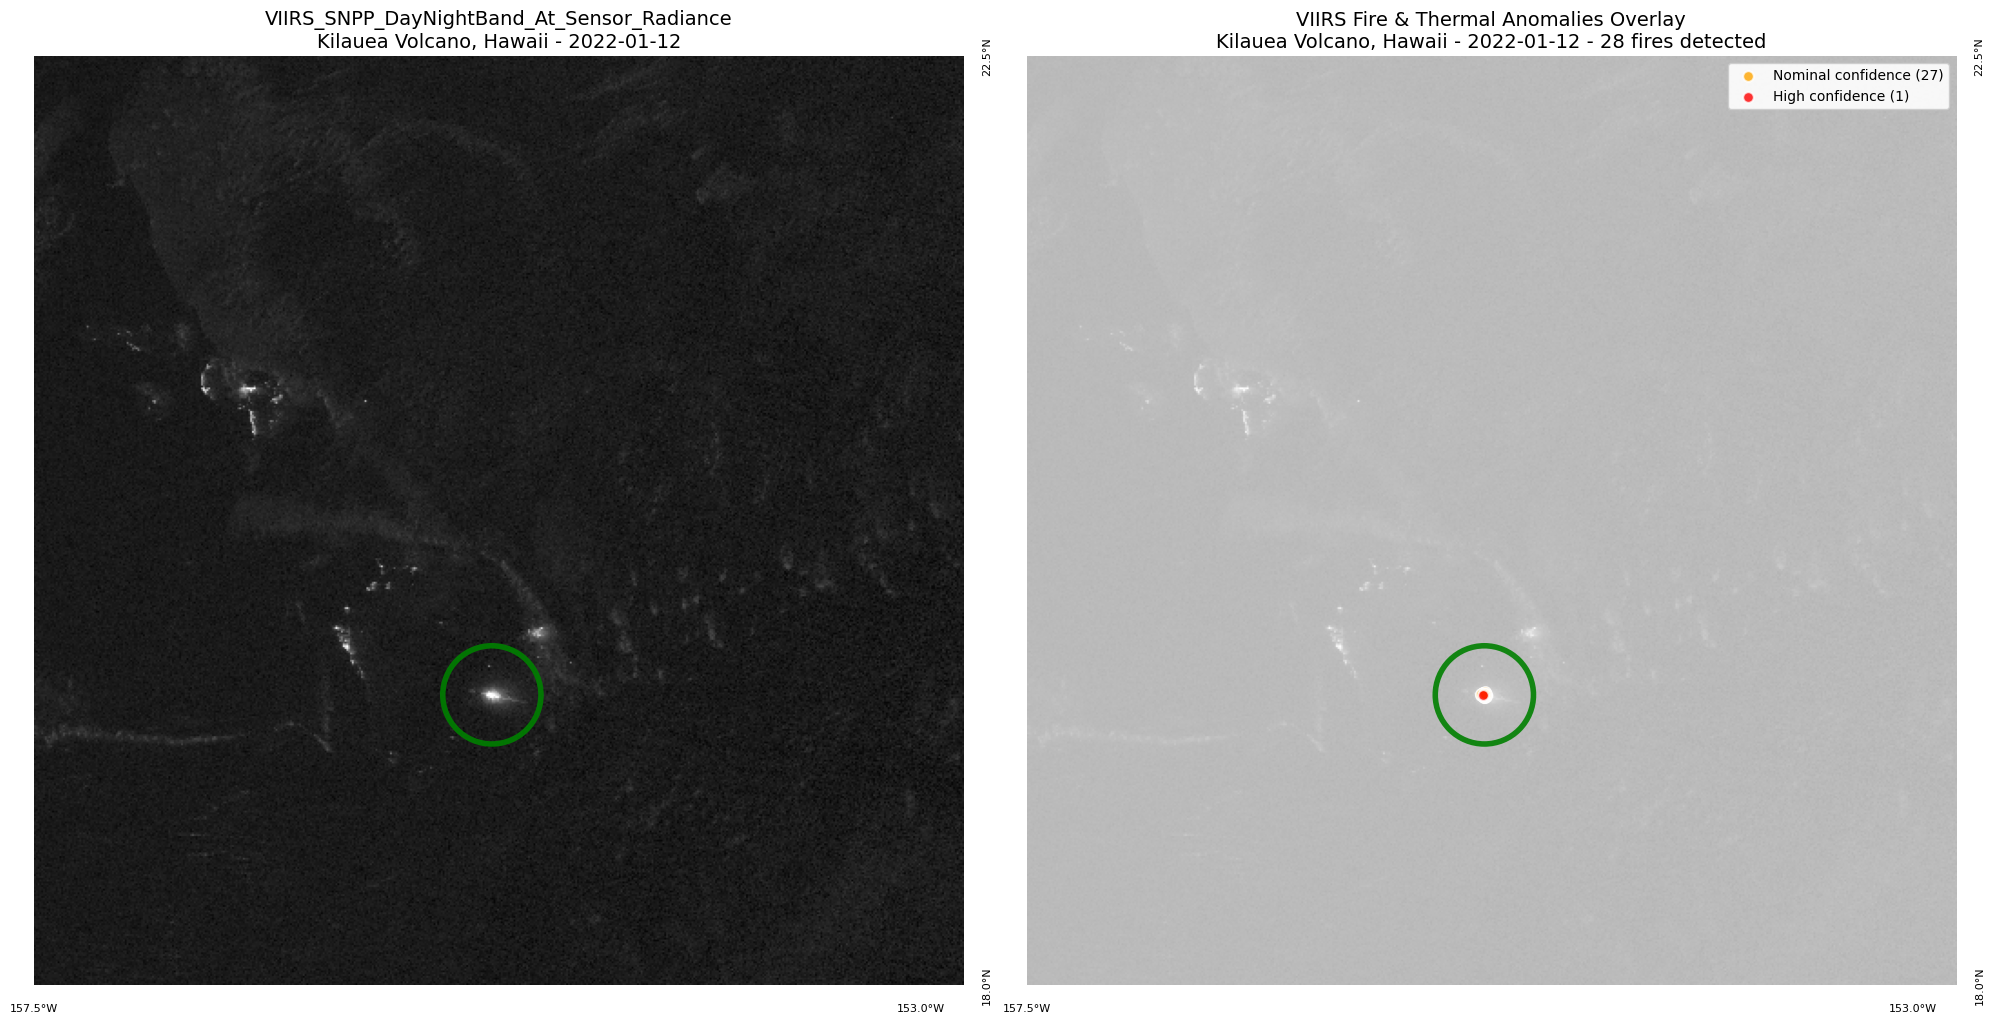

In [12]:
# Create side-by-side visualization with Black Marble and Fire overlay
%matplotlib inline

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Get data
bbox = data['bbox']
fires = data['fires']
black_marble_tiles = data['black_marble_tiles']
location = data['location']
lon = data['lon']
lat = data['lat']
date = data['date']
zoom = data['zoom']

# Left plot: Black Marble
ax1.set_xlim(bbox[0], bbox[1])
ax1.set_ylim(bbox[2], bbox[3])

if black_marble_tiles:
    for (col, row), tile_img in black_marble_tiles.items():
        tile_bbox = tile_to_bbox(col, row, zoom)
        ax1.imshow(tile_img, extent=tile_bbox, zorder=1)

# Add large green circle at the location (using geographic coordinates)
ax1.scatter(lon, lat, facecolors='none', edgecolors='green', s=5000, marker='o', linewidths=4, alpha=0.9, zorder=5)

ax1.set_title(f"{COLLECTION_NAME}\n{location} - {date[:10]}", fontsize=14)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, alpha=0.3)

# Add coordinate labels for left plot
if zoom >= 2:
    min_lon, max_lon, min_lat, max_lat = bbox
    
    ax1.text(0.0, -0.02, format_coordinate(min_lon, True), 
           transform=ax1.transAxes, ha='center', va='top', fontsize=8)
    ax1.text(0.98, -0.02, format_coordinate(max_lon, True), 
           transform=ax1.transAxes, ha='right', va='top', fontsize=8)
    ax1.text(1.02, 0.0, format_coordinate(min_lat, False), 
           transform=ax1.transAxes, rotation=90, ha='left', va='center', fontsize=8)
    ax1.text(1.02, 1.0, format_coordinate(max_lat, False), 
           transform=ax1.transAxes, rotation=90, ha='left', va='center', fontsize=8)

ax1.axis('off')

# Right plot: Black Marble with Fire overlay
ax2.set_xlim(bbox[0], bbox[1])
ax2.set_ylim(bbox[2], bbox[3])

# Show Black Marble as background (dimmed)
if black_marble_tiles:
    for (col, row), tile_img in black_marble_tiles.items():
        tile_bbox = tile_to_bbox(col, row, zoom)
        ax2.imshow(tile_img, extent=tile_bbox, alpha=0.3, zorder=1)

# Add large green circle at the location (using geographic coordinates)
ax2.scatter(lon, lat, facecolors='none', edgecolors='green', s=5000, marker='o', linewidths=4, alpha=0.9, zorder=2)

# Overlay fire data
if fires:
    conf_colors = {'high': 'red', 'nominal': 'orange', 'low': 'yellow', 'unknown': 'gray'}
    
    # Group fires by confidence for legend
    confidence_groups = {}
    for fire in fires:
        conf = fire['confidence'].lower()
        if conf not in confidence_groups:
            confidence_groups[conf] = []
        confidence_groups[conf].append(fire)
    
    # Plot fires by confidence level
    for conf, fire_list in confidence_groups.items():
        lons = [f['lon'] for f in fire_list]
        lats = [f['lat'] for f in fire_list]
        color = conf_colors.get(conf, 'gray')
        ax2.scatter(lons, lats, c=color, s=60, alpha=0.8,
                   edgecolors='white', linewidths=1.5, zorder=3,
                   label=f'{conf.capitalize()} confidence ({len(fire_list)})')
    
    # Add legend
    ax2.legend(loc='upper right', framealpha=0.9)
    
    ax2.set_title(f"VIIRS Fire & Thermal Anomalies Overlay\n{location} - {date[:10]} - {len(fires)} fires detected", fontsize=14)
else:
    ax2.set_title(f"VIIRS Fire & Thermal Anomalies Overlay\n{location} - {date[:10]} - No fires detected", fontsize=14)

ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add coordinate labels for right plot
if zoom >= 2:
    ax2.text(0.0, -0.02, format_coordinate(min_lon, True), 
           transform=ax2.transAxes, ha='center', va='top', fontsize=8)
    ax2.text(0.98, -0.02, format_coordinate(max_lon, True), 
           transform=ax2.transAxes, ha='right', va='top', fontsize=8)
    ax2.text(1.02, 0.0, format_coordinate(min_lat, False), 
           transform=ax2.transAxes, rotation=90, ha='left', va='center', fontsize=8)
    ax2.text(1.02, 1.0, format_coordinate(max_lat, False), 
           transform=ax2.transAxes, rotation=90, ha='left', va='center', fontsize=8)

ax2.axis('off')

plt.tight_layout()
plt.show()

## Summary

In this notebook we have successfully completed the following steps for the STAC collection for the Black Marble Nighttime at Sensor Radiance dataset:

1.  Install and import the necessary libraries.
2.  Fetch the collection from STAC collections.
3.  Compute WMTS tile indices.
4.  Retrieve and visualize Black Marble nighttime at sensor radiance.
5.  Integrate VIIRS fire and thermal anomaly data.
6.  Create interactive location selection widgets.
7.  Generate side-by-side visualizations.
8.  Distinguish between lights and thermal sources.

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform).